# RWKV from Scratch: Linear Attention as an RNN

In this notebook, we'll implement **RWKV (Receptance Weighted Key Value)**, a novel architecture that combines the efficiency of RNNs with the expressiveness of attention mechanisms.

## What You'll Learn

- Why standard RNNs struggle with long-range dependencies
- How **attention** can be reformulated as an **RNN** (linear complexity!)
- The key innovation: **time-mixing** and **channel-mixing** blocks
- How **exponential decay** creates selective memory
- Building and training RWKV on text generation

## Key Intuition

RWKV asks: *"What if we could get transformer-like performance while maintaining RNN-style sequential processing?"* The answer: use **linear attention** with **exponential decay** weights that can be computed recurrently.

## 1. Configuration

Set all hyperparameters in one place for easy experimentation.

In [1]:
CONFIG = {
    # Data
    "block_size": 32,  # Sequence length for training (reduced for faster testing)
    "vocab_size": None,  # Set after tokenization
    
    # Model architecture
    "n_embed": 64,  # Embedding dimension (reduced for faster training)
    "hidden_size": 128,  # Hidden state dimension (reduced for faster training)
    "n_layers": 1,  # Number of RWKV layers
    
    # Training
    "batch_size": 32,  # Number of sequences per batch (reduced for faster training)
    "n_epochs": 3,  # Maximum training epochs (reduced for testing)
    "learning_rate": 3e-3,  # Optimizer learning rate
    "max_patience": 2,  # Early stopping patience
}

## 2. Load and Prepare Data

We'll use the Lord of the Rings text for character-level language modeling.

In [2]:
with open("data/lotr.txt", "r", encoding="utf-8") as f:
    TEXT = f.read()
TEXT = TEXT.lower()
TEXT[:1000]

"in this reprint several minor inaccuracies, most of them noted by readers, have been corrected. for example, the text on pages 32 and 62 now corresponds exactly with the runes on thror's map. more important is the matter of chapter five. there the true story of the ending of the riddle game, as it was eventually revealed (under pressure) by bilbo to gandalf, is now given according to the red book, in place of the version bilbo first gave to his friends, and actually set down in his diary. this departure from truth on the part of a most honest hobbit was a portent of great significance. it does not, however, concern the present story, and those who in this edition make their first acquaintance with hobbit-lore need not troupe about it. its explanation lies in the history of the ring, as it was set out in the chronicles of the red book of westmarch, and is now told in the lord of the rings.\n\na final note may be added, on a point raised by several students of the lore of the period. on

### Build Character-Level Vocabulary

Create mappings between characters and integers for tokenization.

In [3]:
VOCAB = sorted(list(set(TEXT)))
CONFIG["vocab_size"] = len(VOCAB)
ctoi = dict((c, i) for i, c in enumerate(VOCAB))
itoc = dict((i, c) for i, c in enumerate(VOCAB))
encode = lambda str: [ctoi[c] for c in str]
decode = lambda tokens: "".join([itoc[i] for i in tokens])
len(VOCAB), decode(encode("hello world"))

(77, 'hello world')

### Tokenize the Text

Convert the entire text corpus into a sequence of integers.

In [4]:
TOKENS = encode(TEXT)
print(f"Total tokens: {len(TOKENS)}")
TOKENS[:20]

Total tokens: 3301752


[41, 46, 1, 52, 40, 41, 51, 1, 50, 37, 48, 50, 41, 46, 52, 1, 51, 37, 54, 37]

## 3. Create Dataset

Split the token sequence into fixed-length chunks for training. Each chunk becomes a training example where we predict the next character at each position.

In [5]:
import torch
from torch.utils.data import Dataset

class ChunkedDataset(Dataset):
    """Split token sequence into fixed-size chunks."""
    def __init__(self, tokens, block_size=CONFIG["block_size"]):
        tokens = torch.tensor(tokens)
        
        # Each chunk needs block_size+1 tokens (input + target)
        n_chunks = len(tokens) // (block_size + 1)
        tokens = tokens[:n_chunks * (block_size + 1)]
        
        self.chunks = tokens.view(n_chunks, block_size + 1)
    
    def __getitem__(self, idx):
        chunk = self.chunks[idx]
        x = chunk[:-1]  # Input: all but last
        y = chunk[1:]   # Target: all but first (shifted by 1)
        return x, y
    
    def __len__(self):
        return len(self.chunks)

full_dataset = ChunkedDataset(TOKENS)
print(f"Total chunks: {len(full_dataset)}")
x_sample, y_sample = full_dataset[0]
print(f"Sample input shape: {x_sample.shape}")
print(f"Sample input: '{decode(x_sample.tolist())}'")
print(f"Sample target: '{decode(y_sample.tolist())}'")

Total chunks: 100053
Sample input shape: torch.Size([32])
Sample input: 'in this reprint several minor in'
Sample target: 'n this reprint several minor ina'


### Split into Train and Validation Sets

Create a wrapper to subset the dataset without duplicating data.

In [6]:
class DatasetSplit(Dataset):
    """Subset a dataset using indices."""
    def __init__(self, dataset, indices):
        self.dataset = dataset
        self.indices = indices
    
    def __getitem__(self, idx):
        dataset_idx = self.indices[idx]
        return self.dataset[dataset_idx]
    
    def __len__(self):
        return len(self.indices)

### Create Train/Val Split

Randomly shuffle and split the dataset 80/20.

In [7]:
import random
random.seed(42)

indices = list(range(len(full_dataset)))
random.shuffle(indices)
split_idx = int(len(indices) * 0.8)
train_indices = indices[:split_idx]
val_indices = indices[split_idx:]

train_dataset = DatasetSplit(full_dataset, train_indices)
val_dataset = DatasetSplit(full_dataset, val_indices)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")

Train samples: 80042
Val samples: 20011


## 4. Create DataLoaders

Batch the data for efficient training.

In [8]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    train_dataset,
    shuffle=True,
    batch_size=CONFIG["batch_size"]
)

val_dataloader = DataLoader(
    val_dataset,
    shuffle=False,
    batch_size=CONFIG["batch_size"]
)

# Verify shapes
x_batch, y_batch = next(iter(train_dataloader))
print(f"Batch input shape: {x_batch.shape}")  # (batch_size, block_size)
print(f"Batch target shape: {y_batch.shape}")  # (batch_size, block_size)

Batch input shape: torch.Size([32, 32])
Batch target shape: torch.Size([32, 32])


## 5. Understanding RWKV

### The Problem with Standard RNNs

Standard RNNs compute: `h_t = tanh(W_x * x_t + W_h * h_{t-1})`

This has a **fixed forgetting rate** - the network can't easily decide what to remember and what to forget.

### The Transformer Solution

Transformers use attention: each position can look at **all previous positions** with learned weights. But this requires O(T²) memory and compute.

### The RWKV Innovation

RWKV reformulates attention to be computed **recurrently**:
- Use **exponential decay** weights for the past (w parameter)
- Maintain a **running state** that summarizes history
- **Linear complexity** O(T) instead of O(T²)

Key equation:
```
wkv_t = (exp(u + k_t) * v_t + state_{t-1}) / (exp(u + k_t) + state_denominator_{t-1})
```

Where:
- **k** (key): what information is important
- **v** (value): what information to store
- **r** (receptance): how much to use this information
- **w** (weight decay): how quickly to forget the past

## 6. Implement Time Mixing Block

The **time mixing** block is where RWKV processes sequential information. It interpolates between the current and previous timestep using learnable mixing parameters.

In [9]:
import torch.nn as nn
import torch.nn.functional as F

class TimeMixing(nn.Module):
    """RWKV time mixing block - processes sequential dependencies."""
    def __init__(self, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        
        # Mixing parameters (learnable interpolation weights)
        self.time_mix_k = nn.Parameter(torch.ones(1, 1, hidden_size))
        self.time_mix_v = nn.Parameter(torch.ones(1, 1, hidden_size))
        self.time_mix_r = nn.Parameter(torch.ones(1, 1, hidden_size))
        
        # Projection layers
        self.key = nn.Linear(hidden_size, hidden_size, bias=False)
        self.value = nn.Linear(hidden_size, hidden_size, bias=False)
        self.receptance = nn.Linear(hidden_size, hidden_size, bias=False)
        self.output = nn.Linear(hidden_size, hidden_size, bias=False)
        
        # Time decay (how quickly to forget)
        self.time_decay = nn.Parameter(torch.ones(hidden_size))
        self.time_first = nn.Parameter(torch.ones(hidden_size))
    
    def forward(self, x):
        B, T, C = x.shape
        
        # Initialize with zeros for first timestep
        x_prev = F.pad(x, (0, 0, 1, 0))[:, :-1, :]  # Shift right
        
        # Mix current and previous timestep
        xk = x * self.time_mix_k + x_prev * (1 - self.time_mix_k)
        xv = x * self.time_mix_v + x_prev * (1 - self.time_mix_v)
        xr = x * self.time_mix_r + x_prev * (1 - self.time_mix_r)
        
        # Compute receptance, key, value
        r = torch.sigmoid(self.receptance(xr))  # Gate: how much to use
        k = self.key(xk)  # What's important
        v = self.value(xv)  # What to store
        
        # Apply WKV (weighted key-value) mechanism
        # This is the "attention" computed recurrently
        wkv = self._wkv(k, v, self.time_decay, self.time_first)
        
        # Apply receptance gate and output projection
        out = self.output(r * wkv)
        return out
    
    def _wkv(self, k, v, w, u):
        """Weighted Key-Value: the core RWKV attention mechanism.
        
        This is the TRUE linear-time O(T) implementation using recurrent state updates.
        """
        B, T, C = k.shape
        
        # Initialize output and running states
        out = torch.zeros_like(v)
        state_num = torch.zeros(B, C, device=k.device)  # Numerator state
        state_den = torch.zeros(B, C, device=k.device)  # Denominator state
        
        # Decay weight (negative exponential for stability)
        w = -torch.exp(w)
        
        # Process each timestep recurrently (this is O(T), not O(T²)!)
        for t in range(T):
            kt = k[:, t, :]  # (B, C)
            vt = v[:, t, :]  # (B, C)
            
            # Current timestep's contribution (with bonus u)
            ek_u = torch.exp(u + kt)
            wkv_num = ek_u * vt + state_num
            wkv_den = ek_u + state_den
            
            # Output for this timestep
            out[:, t, :] = wkv_num / wkv_den
            
            # Update states for next timestep (exponential decay of past)
            ek = torch.exp(kt)
            state_num = ek * vt + torch.exp(w) * state_num
            state_den = ek + torch.exp(w) * state_den
        
        return out

### Test Time Mixing

Verify the time mixing block processes sequences correctly.

In [10]:
# Test with random input
test_input = torch.randn(2, 10, CONFIG["hidden_size"])  # (B=2, T=10, C=hidden_size)
time_mix = TimeMixing(CONFIG["hidden_size"])
test_output = time_mix(test_input)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {test_output.shape}")
print(f"Output preserves shape: {test_output.shape == test_input.shape}")

Input shape: torch.Size([2, 10, 128])
Output shape: torch.Size([2, 10, 128])
Output preserves shape: True


## 7. Implement Channel Mixing Block

The **channel mixing** block processes information across feature dimensions. It's similar to a feedforward network but uses the same time-mixing principle.

In [11]:
class ChannelMixing(nn.Module):
    """RWKV channel mixing block - processes feature dependencies."""
    def __init__(self, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        
        # Mixing parameters
        self.time_mix_k = nn.Parameter(torch.ones(1, 1, hidden_size))
        self.time_mix_r = nn.Parameter(torch.ones(1, 1, hidden_size))
        
        # Feedforward layers (4x expansion typical in transformers)
        self.key = nn.Linear(hidden_size, 4 * hidden_size, bias=False)
        self.receptance = nn.Linear(hidden_size, hidden_size, bias=False)
        self.value = nn.Linear(4 * hidden_size, hidden_size, bias=False)
    
    def forward(self, x):
        # Shift and mix with previous timestep
        x_prev = F.pad(x, (0, 0, 1, 0))[:, :-1, :]
        
        xk = x * self.time_mix_k + x_prev * (1 - self.time_mix_k)
        xr = x * self.time_mix_r + x_prev * (1 - self.time_mix_r)
        
        # Compute receptance and key
        r = torch.sigmoid(self.receptance(xr))
        k = self.key(xk)
        
        # Apply squared ReLU activation (more stable than ReLU)
        k = torch.relu(k) ** 2
        
        # Project back and gate
        out = r * self.value(k)
        return out

### Test Channel Mixing

Verify the channel mixing block processes features correctly.

In [12]:
# Test with random input
test_input = torch.randn(2, 10, CONFIG["hidden_size"])
channel_mix = ChannelMixing(CONFIG["hidden_size"])
test_output = channel_mix(test_input)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {test_output.shape}")
print(f"Output preserves shape: {test_output.shape == test_input.shape}")

Input shape: torch.Size([2, 10, 128])
Output shape: torch.Size([2, 10, 128])
Output preserves shape: True


## 8. Implement RWKV Block

Combine time mixing and channel mixing with layer normalization and residual connections.

In [13]:
class RWKVBlock(nn.Module):
    """Single RWKV block = LayerNorm + TimeMix + LayerNorm + ChannelMix (with residuals)."""
    def __init__(self, hidden_size):
        super().__init__()
        self.ln1 = nn.LayerNorm(hidden_size)
        self.ln2 = nn.LayerNorm(hidden_size)
        self.time_mixing = TimeMixing(hidden_size)
        self.channel_mixing = ChannelMixing(hidden_size)
    
    def forward(self, x):
        # Time mixing with residual
        x = x + self.time_mixing(self.ln1(x))
        # Channel mixing with residual
        x = x + self.channel_mixing(self.ln2(x))
        return x

## 9. Implement Full RWKV Model

Stack multiple RWKV blocks with embedding and output layers.

In [14]:
class RWKV(nn.Module):
    """Full RWKV model for language modeling."""
    def __init__(
        self,
        vocab_size=CONFIG["vocab_size"],
        n_embed=CONFIG["n_embed"],
        hidden_size=CONFIG["hidden_size"],
        n_layers=CONFIG["n_layers"]
    ):
        super().__init__()
        
        # Embedding layer
        self.embeddings = nn.Embedding(vocab_size, n_embed)
        
        # Project embeddings to hidden size if different
        self.embed_proj = nn.Linear(n_embed, hidden_size, bias=False) if n_embed != hidden_size else nn.Identity()
        
        # Stack of RWKV blocks
        self.blocks = nn.ModuleList([RWKVBlock(hidden_size) for _ in range(n_layers)])
        
        # Output layer
        self.ln_out = nn.LayerNorm(hidden_size)
        self.head = nn.Linear(hidden_size, vocab_size, bias=False)
    
    def forward(self, x):
        # Embed tokens
        x = self.embeddings(x)  # (B, T) -> (B, T, n_embed)
        x = self.embed_proj(x)  # (B, T, n_embed) -> (B, T, hidden_size)
        
        # Pass through RWKV blocks
        for block in self.blocks:
            x = block(x)  # (B, T, hidden_size) -> (B, T, hidden_size)
        
        # Output projection
        x = self.ln_out(x)  # (B, T, hidden_size)
        logits = self.head(x)  # (B, T, hidden_size) -> (B, T, vocab_size)
        
        return logits

### Initialize and Test Model

Create the model and verify it processes a batch correctly.

In [15]:
model = RWKV()

# Test forward pass
x_test, _ = next(iter(train_dataloader))
logits = model(x_test)

print(f"Input shape: {x_test.shape}")
print(f"Output logits shape: {logits.shape}")
print(f"Expected shape: (batch={CONFIG['batch_size']}, seq_len={CONFIG['block_size']}, vocab={CONFIG['vocab_size']})")

# Count parameters
n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {n_params:,}")

Input shape: torch.Size([32, 32])
Output logits shape: torch.Size([32, 32, 77])
Expected shape: (batch=32, seq_len=32, vocab=77)

Total parameters: 237,632


## 10. Implement Evaluation Function

Compute validation loss without updating gradients.

In [16]:
from tqdm import tqdm

@torch.no_grad()
def evaluate(model, loader):
    """Evaluate model on a dataset."""
    model.eval()
    losses = []
    
    for x, y in tqdm(loader, disable=True):
        logits = model(x)  # (B, T, V)
        logits = logits.reshape(-1, logits.size(-1))  # (B*T, V)
        y = y.reshape(-1)  # (B*T,)
        loss = F.cross_entropy(logits, y)
        losses.append(loss.item())
    
    return sum(losses) / len(losses)

# Test evaluation
initial_loss = evaluate(model, val_dataloader)
print(f"Initial validation loss: {initial_loss:.4f}")
print(f"Random chance loss (log({CONFIG['vocab_size']})): {torch.log(torch.tensor(CONFIG['vocab_size'])).item():.4f}")

Initial validation loss: 4.5137
Random chance loss (log(77)): 4.3438


## 11. Training Loop

Train the RWKV model with early stopping based on validation loss.

In [17]:
import time
import torch.optim

start = time.time()
n_epochs = CONFIG["n_epochs"]
lr = CONFIG["learning_rate"]
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

train_losses = []
val_losses = []
patience = max_patience = CONFIG["max_patience"]

for epoch in range(n_epochs):
    model.train()
    losses = []
    pbar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{n_epochs}")
    
    for x, y in pbar:
        # Forward pass
        logits = model(x)
        logits = logits.reshape(-1, logits.size(-1))  # (B*T, V)
        y = y.reshape(-1)  # (B*T,)
        loss = F.cross_entropy(logits, y)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        pbar.set_postfix({"train_loss": loss.item()})
    
    # Compute epoch metrics
    train_loss = sum(losses) / len(losses)
    val_loss = evaluate(model, val_dataloader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, patience={patience}")
    
    # Early stopping check
    if len(val_losses) > 1:
        val_loss_delta = val_losses[-2] - val_losses[-1]
        if val_loss_delta > 0.01:
            patience = max_patience
        else:
            patience -= 1
            if patience == 0:
                print("Early stopping due to validation loss plateau")
                break

elapsed = time.time() - start
print(f"\nTraining finished in {elapsed:.1f}s")
print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final val loss: {val_losses[-1]:.4f}")

Epoch 1/3:   0%|          | 0/2502 [00:00<?, ?it/s]

Epoch 1/3:   0%|          | 0/2502 [00:00<?, ?it/s, train_loss=4.52]

Epoch 1/3:   0%|          | 0/2502 [00:00<?, ?it/s, train_loss=3.64]

Epoch 1/3:   0%|          | 0/2502 [00:00<?, ?it/s, train_loss=3.26]

Epoch 1/3:   0%|          | 3/2502 [00:00<01:35, 26.22it/s, train_loss=3.26]

...

Epoch 3/3: 100%|█████████▉| 2499/2502 [01:12<00:00, 35.88it/s, train_loss=1.37]

Epoch 3/3: 100%|█████████▉| 2499/2502 [01:12<00:00, 35.88it/s, train_loss=1.32]

Epoch 3/3: 100%|█████████▉| 2499/2502 [01:12<00:00, 35.88it/s, train_loss=1.4] 

Epoch 3/3: 100%|██████████| 2502/2502 [01:12<00:00, 34.37it/s, train_loss=1.4]

Epoch 3: train_loss=1.3967, val_loss=1.3965, patience=2

Training finished in 235.9s
Final train loss: 1.3967
Final val loss: 1.3965


## 12. Plot Training Curves

Visualize how the model learned over time.

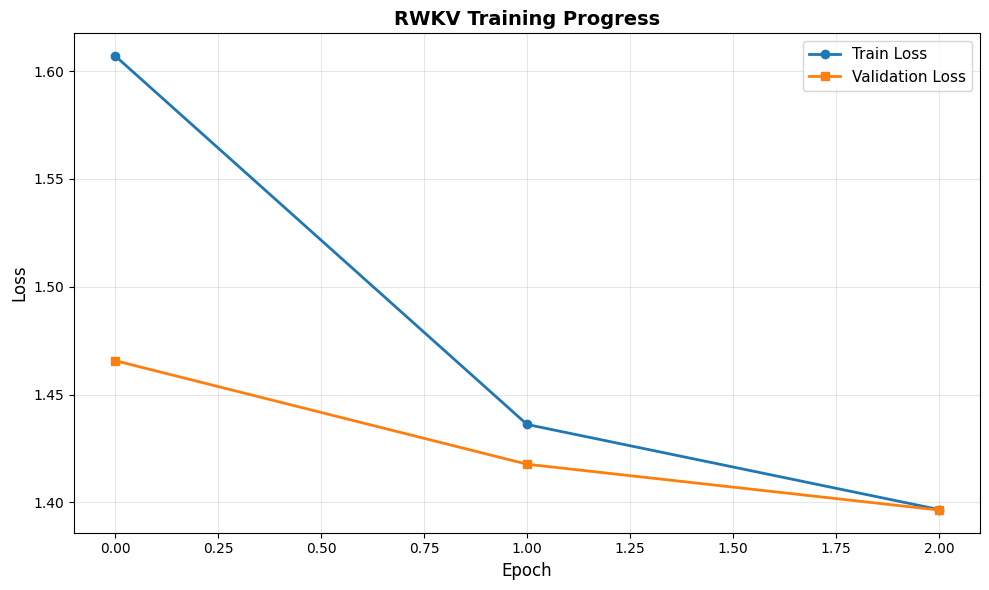

Best validation loss: 1.3965 at epoch 3


In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss', marker='o', linewidth=2)
plt.plot(val_losses, label='Validation Loss', marker='s', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('RWKV Training Progress', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best validation loss: {min(val_losses):.4f} at epoch {val_losses.index(min(val_losses)) + 1}")

## 13. Text Generation

Test the trained model by generating text from a prompt.

In [19]:
def generate(model, prompt, max_len=100, temperature=1.0):
    """Generate text continuation from a prompt."""
    model.eval()
    tokens = encode(prompt)
    max_new_tokens = max_len - len(tokens)
    assert max_new_tokens > 0, "max_len must be greater than prompt length"
    
    print(prompt, end="")
    
    with torch.no_grad():
        for _ in range(max_new_tokens):
            # Get predictions for current sequence
            tokens_t = torch.tensor(tokens).unsqueeze(0)  # (1, T)
            logits = model(tokens_t)  # (1, T, vocab_size)
            logits = logits[:, -1, :] / temperature  # (1, vocab_size) - only last position
            
            # Sample next token
            probs = F.softmax(logits, dim=-1)
            token = torch.multinomial(probs, num_samples=1).squeeze().item()
            
            # Append and print
            tokens.append(token)
            print(decode([token]), end="")
    
    print()  # Newline at end

### Generate Sample Text

Try generating text from different prompts.

In [20]:
# Generate from a prompt
generate(model, "frodo picked up the ", max_len=100)

frodo picked up the house could pinnacles upon that, but battle even at had vanishing and chasm. the


In [21]:
# Try another prompt
generate(model, "gandalf said ", max_len=100)

gandalf said such now."

come send m

arch, 

and this to help as a feast of deeming, swood-ton-cloaked 


In [22]:
# Try with lower temperature (more focused)
generate(model, "the ring of power ", max_len=100, temperature=0.8)

the ring of power of when deep by gand

alf.

the middle

 and

 short wandered by made who had been as im


## 14. Key Takeaways

### What We Learned

1. **RWKV bridges RNNs and Transformers**: It achieves transformer-like expressiveness with RNN-like efficiency (linear complexity)

2. **Time Mixing is the key innovation**: By interpolating between current and previous timesteps with learnable weights, RWKV can adaptively remember or forget information

3. **Exponential decay creates selective memory**: The `w` parameter controls how quickly past information decays, allowing the model to maintain relevant long-range dependencies

4. **Parallel training, sequential inference**: RWKV can be trained in parallel like transformers, but runs sequentially during inference like RNNs

5. **Receptance, Key, Value, Weight**: These four components work together:
   - **Key**: determines what information is important
   - **Value**: stores the actual information
   - **Receptance**: gates how much to use the computed values
   - **Weight**: controls the decay of past information

### Why This Matters

RWKV offers a promising alternative to transformers for long sequences, combining:
- **Efficiency**: O(T) complexity instead of O(T²)
- **Performance**: Competitive with transformers on many tasks
- **Flexibility**: Can process arbitrary length sequences without retraining

### Further Exploration

- Try increasing `n_layers` to see if deeper models perform better
- Experiment with different `hidden_size` values
- Compare training time and memory usage with a transformer
- Visualize the learned `time_decay` and mixing parameters
- Implement the fully recurrent version for inference (constant memory!)